# Additional EDA: Comprehensive Hotel Data Analysis
In-depth analysis of various factors affecting hotel prices and patterns.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

## Load Data

In [22]:
df = pd.read_csv('../data/enriched_hotels_data.csv')
df['search_date'] = pd.to_datetime(df['search_date'], format='%d.%m.%Y')
print(f"Total records: {len(df)}")
print(f"Date range: {df['search_date'].min()} to {df['search_date'].max()}")
print(f"Columns: {list(df.columns)}")
df.head()

Total records: 1923
Date range: 2026-01-05 00:00:00 to 2026-12-07 00:00:00
Columns: ['search_date', 'day_of_week', 'location', 'hotel_id', 'hotel_name', 'price', 'currency', 'rating', 'address', 'city_code', 'latitude', 'longitude', 'distance_from_center', 'amenities', 'room_type', 'board_type', 'altitude', 'canton', 'destination_type', 'distance_to_airport_km', 'month', 'quarter', 'week_of_year', 'day_of_year', 'is_weekend', 'season', 'is_public_holiday', 'is_school_vacation', 'temp_avg', 'temp_min', 'temp_max', 'precipitation_mm', 'snow_depth_cm', 'sunshine_hours', 'is_ski_season', 'hotel_chain', 'is_chain_hotel']


,search_date,day_of_week,location,hotel_id,hotel_name,price,currency,rating,address,city_code,...,is_school_vacation,temp_avg,temp_min,temp_max,precipitation_mm,snow_depth_cm,sunshine_hours,is_ski_season,hotel_chain,is_chain_hotel
0,2026-01-05,Monday,Arosa,BWZRH091,BEST WESTERN HOTEL ZURCHERHOF,570.64,CHF,4.5,"Poststrasse 95, Arosa",ZRH,...,False,-8.2,-11.3,-2.6,4.0,126,4.1,True,Best Western,True
1,2026-01-05,Monday,Arosa,MCZRHDTM,Zurich Marriott Hotel,732.90,CHF,4.5,"Marktplatz 10, Arosa",ZRH,...,False,-5.6,-11.0,-0.9,1.3,64,1.4,True,Marriott,True
2,2026-01-05,Monday,Arosa,ONZRHCTY,HOTEL CITY,438.36,CHF,4.3,"Hauptstrasse 54, Arosa",ZRH,...,False,-6.8,-12.6,-1.4,1.5,142,3.5,True,Independent,False
3,2026-01-05,Monday,Arosa,ONZRHMOT,HOTEL MONTANA,301.46,CHF,4.1,"Poststrasse 9, Arosa",ZRH,...,False,-9.5,-14.4,-5.1,0.0,94,1.3,True,Independent,False
4,2026-01-05,Monday,Arosa,XKZRH001,Hotel du Lac,239.68,CHF,3.9,"Bahnhofstrasse 13, Arosa",ZRH,...,False,-4.9,-9.0,1.9,1.6,131,2.9,True,Independent,False


## 1. Price vs Rating Analysis

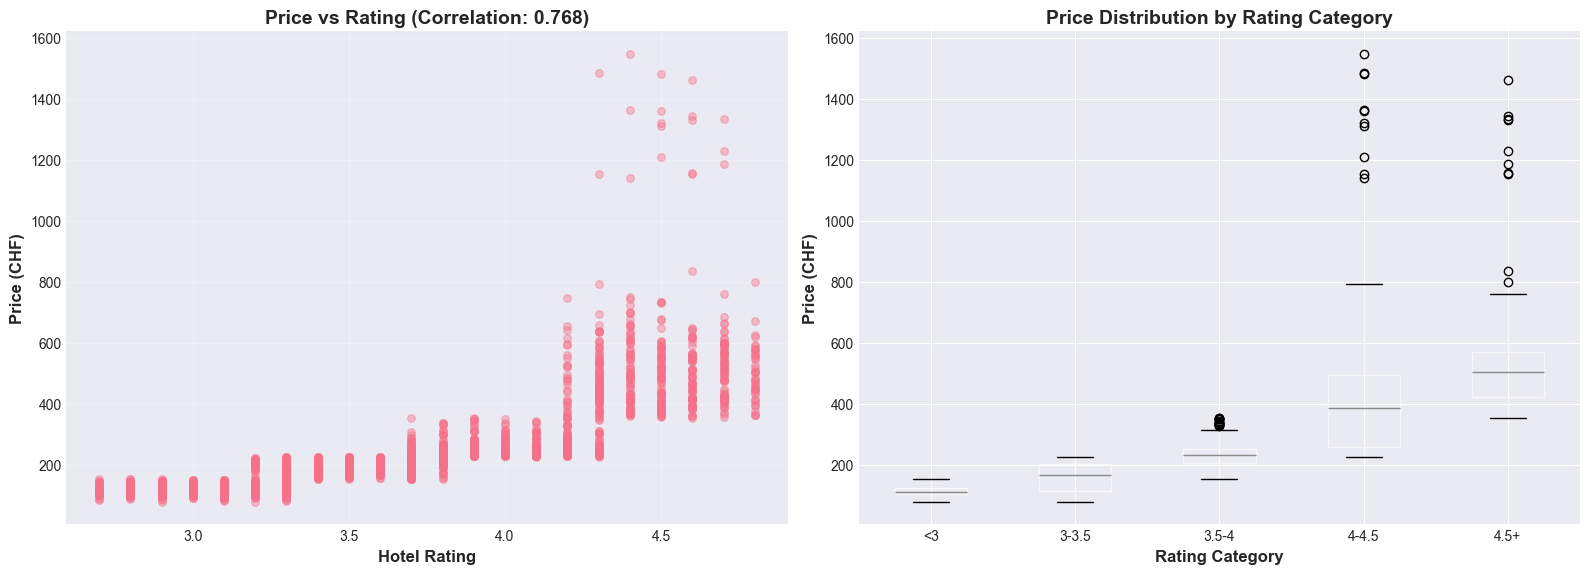


Price Statistics by Rating Category:
                   mean  median  count
rating_category                       
<3               115.99  111.55    269
3-3.5            160.75  165.27    482
3.5-4            231.75  231.71    479
4-4.5            409.38  386.10    504
4.5+             532.92  503.36    189


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['rating'], df['price'], alpha=0.4, s=30)
correlation_rating = df['price'].corr(df['rating'])
axes[0].set_xlabel('Hotel Rating', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (CHF)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Price vs Rating (Correlation: {correlation_rating:.3f})', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

rating_bins = [0, 3, 3.5, 4, 4.5, 5]
df['rating_category'] = pd.cut(df['rating'], bins=rating_bins, 
                               labels=['<3', '3-3.5', '3.5-4', '4-4.5', '4.5+'])
df.boxplot(column='price', by='rating_category', ax=axes[1])
axes[1].set_xlabel('Rating Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price (CHF)', fontsize=12, fontweight='bold')
axes[1].set_title('Price Distribution by Rating Category', fontsize=14, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

rating_stats = df.groupby('rating_category', observed=True)['price'].agg(['mean', 'median', 'count']).round(2)
print("\nPrice Statistics by Rating Category:")
print(rating_stats.to_string())

## 2. Weekend vs Weekday Pricing


NOTE: Dataset contains only weekday data
Total records: 1923
All records are from weekdays

Weekday Price Statistics:
  Mean: 273.92 CHF
  Median: 226.83 CHF
  Std Dev: 179.08 CHF


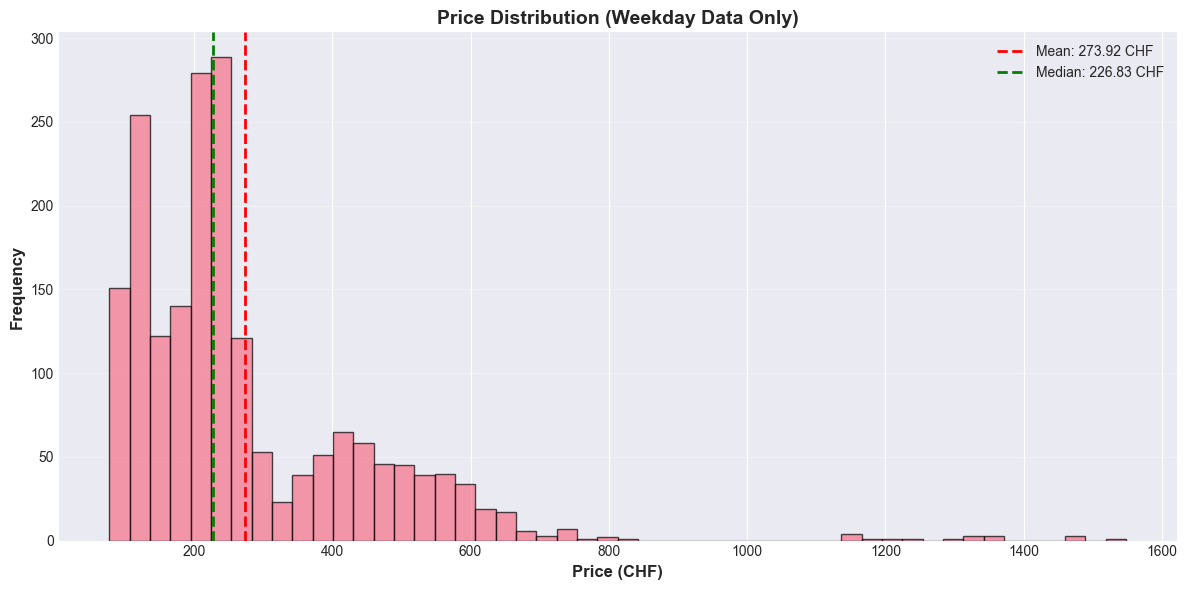

In [24]:
# Check if we have weekend data
weekend_counts = df['is_weekend'].value_counts()
has_weekend_data = len(weekend_counts) > 1

if has_weekend_data:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    weekend_comparison = df.groupby('is_weekend')['price'].mean()
    axes[0].bar(['Weekday', 'Weekend'], weekend_comparison.values, color=['skyblue', 'coral'], edgecolor='black')
    axes[0].set_ylabel('Average Price (CHF)', fontsize=12, fontweight='bold')
    axes[0].set_title('Average Price: Weekday vs Weekend', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(weekend_comparison.values):
        axes[0].text(i, v, f'{v:.2f} CHF', ha='center', va='bottom', fontweight='bold')
    
    df.boxplot(column='price', by='is_weekend', ax=axes[1])
    axes[1].set_xticklabels(['Weekday', 'Weekend'])
    axes[1].set_ylabel('Price (CHF)', fontsize=12, fontweight='bold')
    axes[1].set_title('Price Distribution: Weekday vs Weekend', fontsize=14, fontweight='bold')
    plt.suptitle('')
    
    plt.tight_layout()
    plt.show()
    
    print("\nWeekend Pricing Analysis:")
    weekend_stats = df.groupby('is_weekend')['price'].agg(['mean', 'median', 'std', 'count']).round(2)
    weekend_stats.index = ['Weekday', 'Weekend']
    print(weekend_stats.to_string())
else:
    print("\n" + "="*60)
    print("NOTE: Dataset contains only weekday data")
    print("="*60)
    print(f"Total records: {len(df)}")
    print(f"All records are from weekdays")
    print("\nWeekday Price Statistics:")
    print(f"  Mean: {df['price'].mean():.2f} CHF")
    print(f"  Median: {df['price'].median():.2f} CHF")
    print(f"  Std Dev: {df['price'].std():.2f} CHF")
    print("="*60)
    
    # Show a simple chart of weekday prices
    plt.figure(figsize=(12, 6))
    plt.hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Price (CHF)', fontsize=12, fontweight='bold')
    plt.ylabel('Frequency', fontsize=12, fontweight='bold')
    plt.title('Price Distribution (Weekday Data Only)', fontsize=14, fontweight='bold')
    plt.axvline(df['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["price"].mean():.2f} CHF')
    plt.axvline(df['price'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["price"].median():.2f} CHF')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

## 3. Price by Day of Week

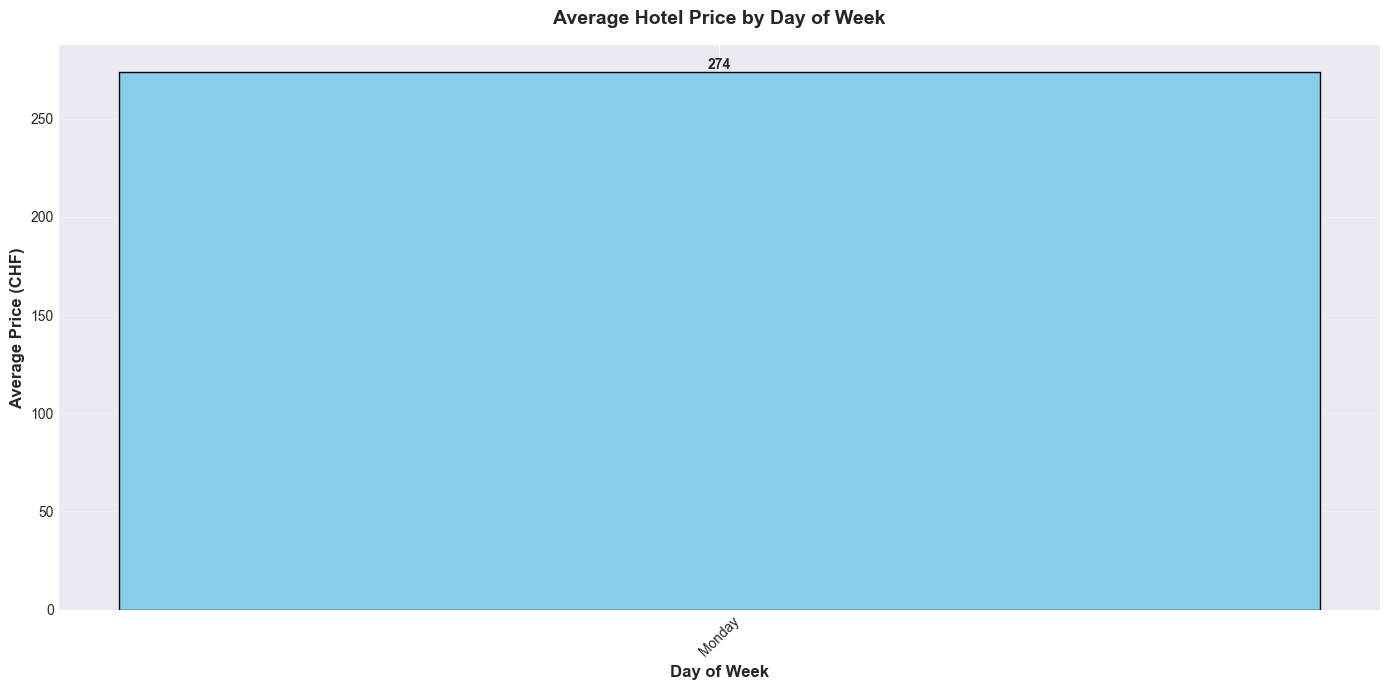


Average Price by Day:
day_of_week
Monday    273.915585


In [25]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

plt.figure(figsize=(14, 7))
day_avg = df.groupby('day_of_week', observed=True)['price'].mean().sort_index()
bars = plt.bar(day_avg.index, day_avg.values, 
              color=['skyblue']*5 + ['coral']*2, edgecolor='black')
plt.xlabel('Day of Week', fontsize=12, fontweight='bold')
plt.ylabel('Average Price (CHF)', fontsize=12, fontweight='bold')
plt.title('Average Hotel Price by Day of Week', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAverage Price by Day:")
print(day_avg.to_string())

## 4. Price by Room Type

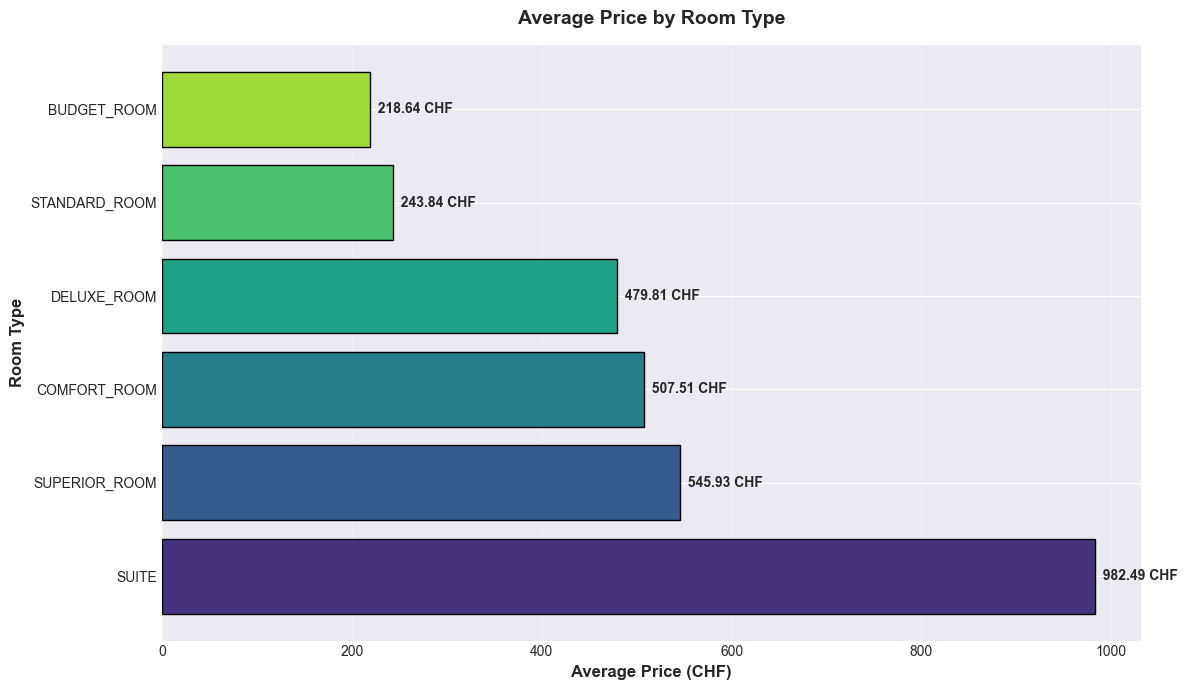


Room Type Statistics:
                 mean  median  count
room_type                           
SUITE          982.49  899.48     16
SUPERIOR_ROOM  545.93  535.68     28
COMFORT_ROOM   507.51  470.83     77
DELUXE_ROOM    479.81  474.28    120
STANDARD_ROOM  243.84  212.20   1243
BUDGET_ROOM    218.64  214.58    439


In [26]:
room_type_avg = df.groupby('room_type')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
bars = plt.barh(room_type_avg.index, room_type_avg.values, 
               color=sns.color_palette("viridis", len(room_type_avg)), edgecolor='black')
plt.xlabel('Average Price (CHF)', fontsize=12, fontweight='bold')
plt.ylabel('Room Type', fontsize=12, fontweight='bold')
plt.title('Average Price by Room Type', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3, axis='x')

for i, (room, price) in enumerate(zip(room_type_avg.index, room_type_avg.values)):
    plt.text(price, i, f'  {price:.2f} CHF', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

room_stats = df.groupby('room_type')['price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False).round(2)
print("\nRoom Type Statistics:")
print(room_stats.to_string())

## 5. Price by Board Type (Meal Plan)

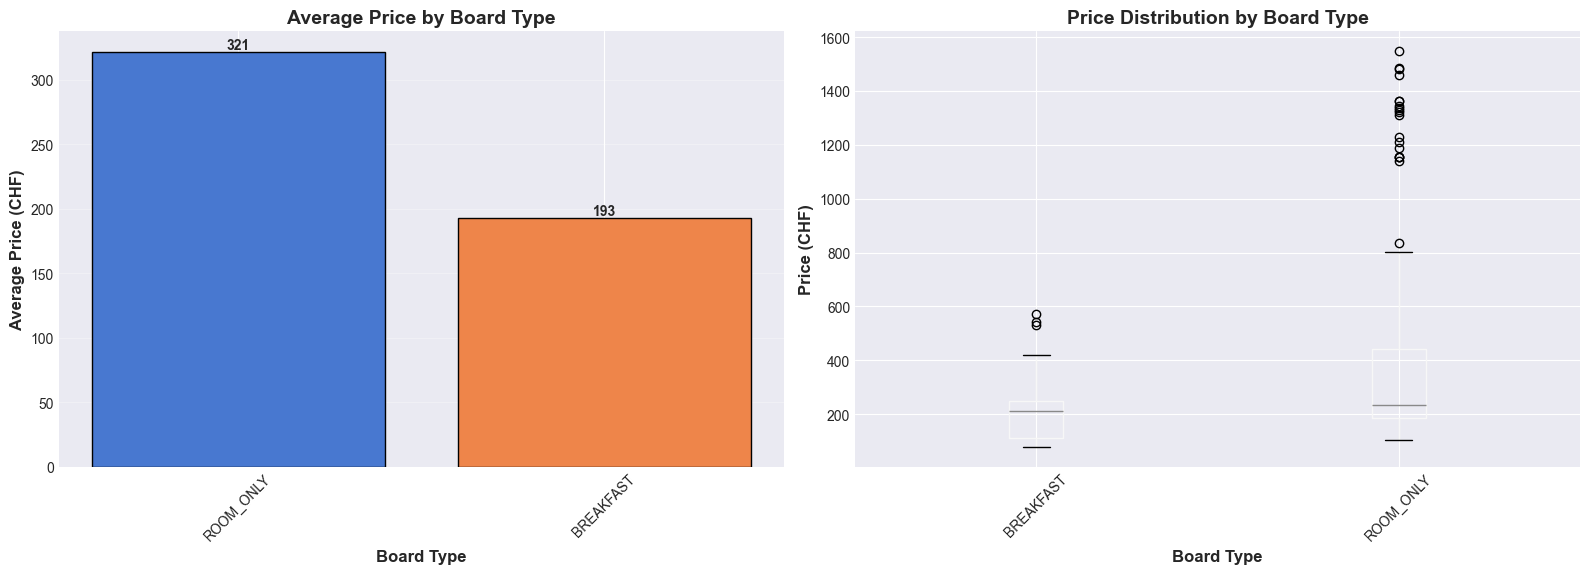


Board Type Statistics:
              mean  median  count
board_type                       
ROOM_ONLY   321.49  231.80   1210
BREAKFAST   193.18  212.27    713


In [27]:
board_type_avg = df.groupby('board_type')['price'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].bar(board_type_avg.index, board_type_avg.values, 
                  color=sns.color_palette("muted", len(board_type_avg)), edgecolor='black')
axes[0].set_xlabel('Board Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Price (CHF)', fontsize=12, fontweight='bold')
axes[0].set_title('Average Price by Board Type', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}', ha='center', va='bottom', fontweight='bold')

df.boxplot(column='price', by='board_type', ax=axes[1])
axes[1].set_xlabel('Board Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price (CHF)', fontsize=12, fontweight='bold')
axes[1].set_title('Price Distribution by Board Type', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle('')

plt.tight_layout()
plt.show()

board_stats = df.groupby('board_type')['price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False).round(2)
print("\nBoard Type Statistics:")
print(board_stats.to_string())

## 6. Chain Hotels vs Independent Hotels

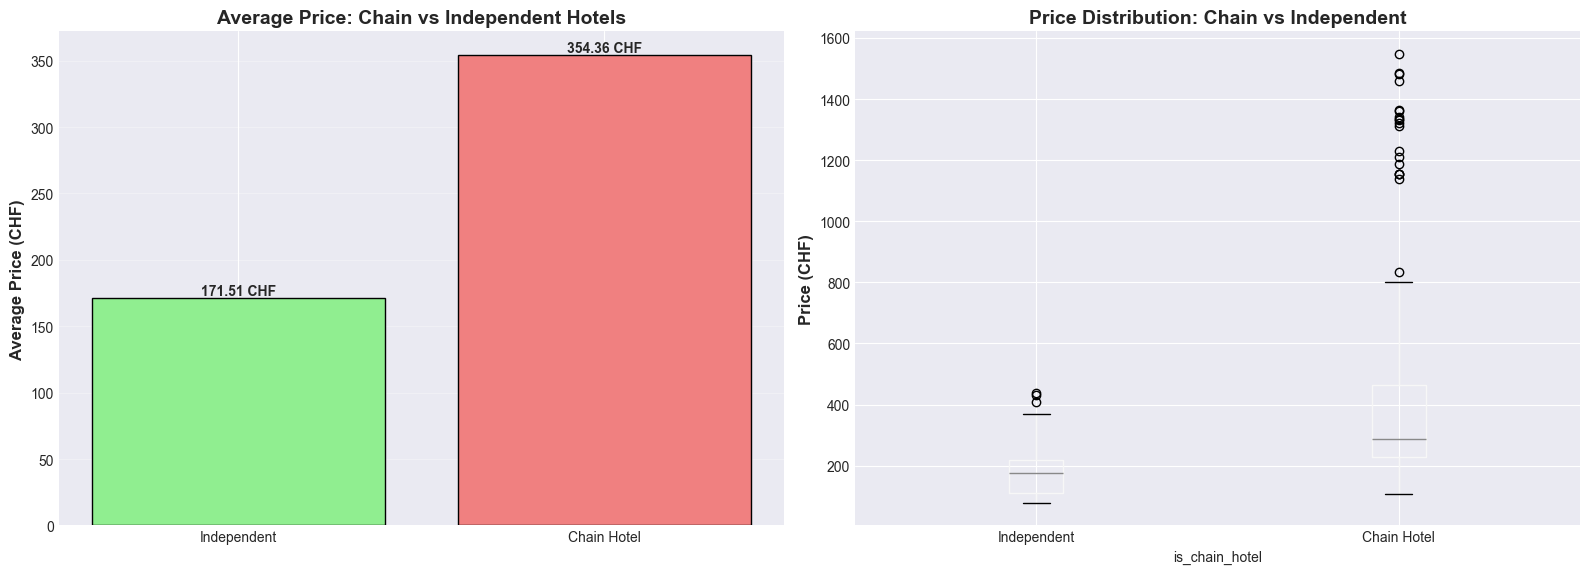


Chain vs Independent Analysis:
               mean  median     std  count
Independent  171.51  174.45   59.93    846
Chain Hotel  354.36  287.00  199.35   1077


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

chain_comparison = df.groupby('is_chain_hotel')['price'].mean()
axes[0].bar(['Independent', 'Chain Hotel'], chain_comparison.values, 
           color=['lightgreen', 'lightcoral'], edgecolor='black')
axes[0].set_ylabel('Average Price (CHF)', fontsize=12, fontweight='bold')
axes[0].set_title('Average Price: Chain vs Independent Hotels', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(chain_comparison.values):
    axes[0].text(i, v, f'{v:.2f} CHF', ha='center', va='bottom', fontweight='bold')

df.boxplot(column='price', by='is_chain_hotel', ax=axes[1])
axes[1].set_xticklabels(['Independent', 'Chain Hotel'])
axes[1].set_ylabel('Price (CHF)', fontsize=12, fontweight='bold')
axes[1].set_title('Price Distribution: Chain vs Independent', fontsize=14, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nChain vs Independent Analysis:")
chain_stats = df.groupby('is_chain_hotel')['price'].agg(['mean', 'median', 'std', 'count']).round(2)
chain_stats.index = ['Independent', 'Chain Hotel']
print(chain_stats.to_string())

## 7. Top Hotel Chains by Average Price

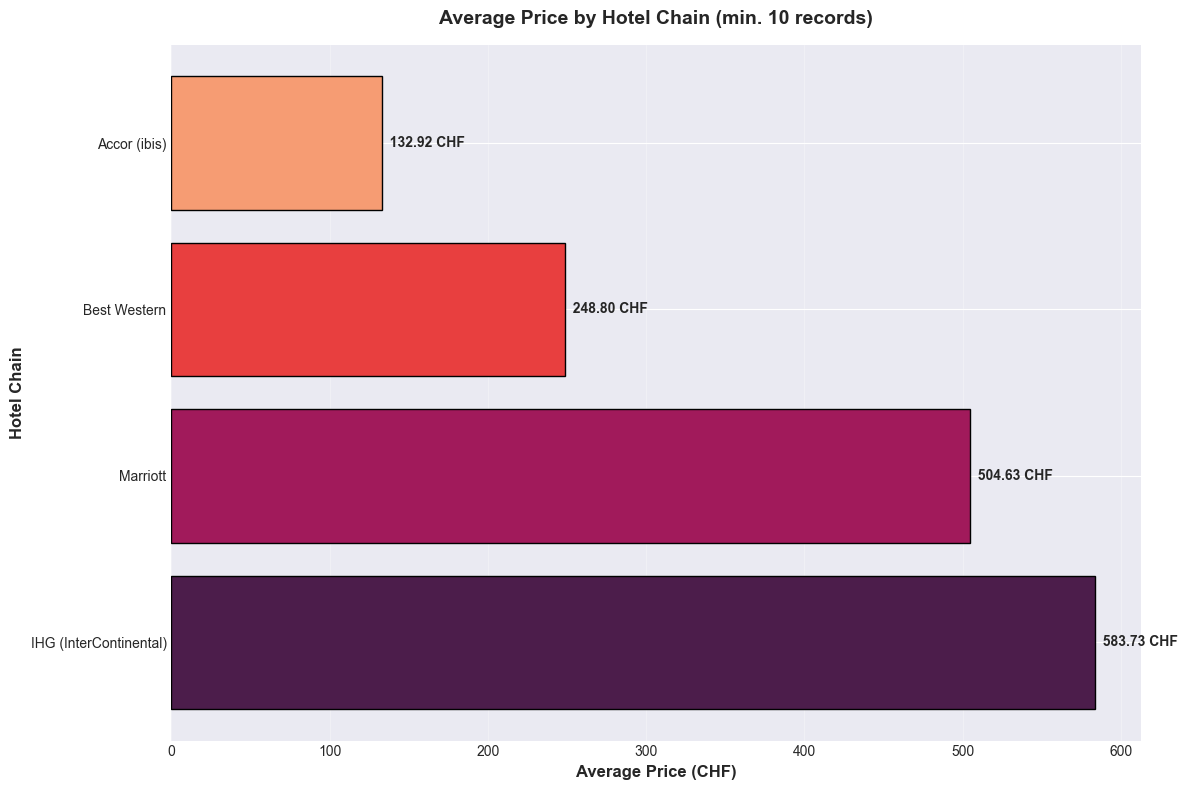


Top Hotel Chains:
                          mean  count
hotel_chain                          
IHG (InterContinental)  583.73     89
Marriott                504.63    394
Best Western            248.80    448
Accor (ibis)            132.92    146


In [29]:
chain_avg = df[df['is_chain_hotel'] == True].groupby('hotel_chain')['price'].agg(['mean', 'count']).sort_values('mean', ascending=False)
chain_avg = chain_avg[chain_avg['count'] >= 10]

plt.figure(figsize=(12, 8))
bars = plt.barh(chain_avg.index, chain_avg['mean'], 
               color=sns.color_palette("rocket", len(chain_avg)), edgecolor='black')
plt.xlabel('Average Price (CHF)', fontsize=12, fontweight='bold')
plt.ylabel('Hotel Chain', fontsize=12, fontweight='bold')
plt.title('Average Price by Hotel Chain (min. 10 records)', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3, axis='x')

for i, (chain, price) in enumerate(zip(chain_avg.index, chain_avg['mean'])):
    plt.text(price, i, f'  {price:.2f} CHF', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop Hotel Chains:")
print(chain_avg.round(2).to_string())

## 8. Seasonal Price Analysis

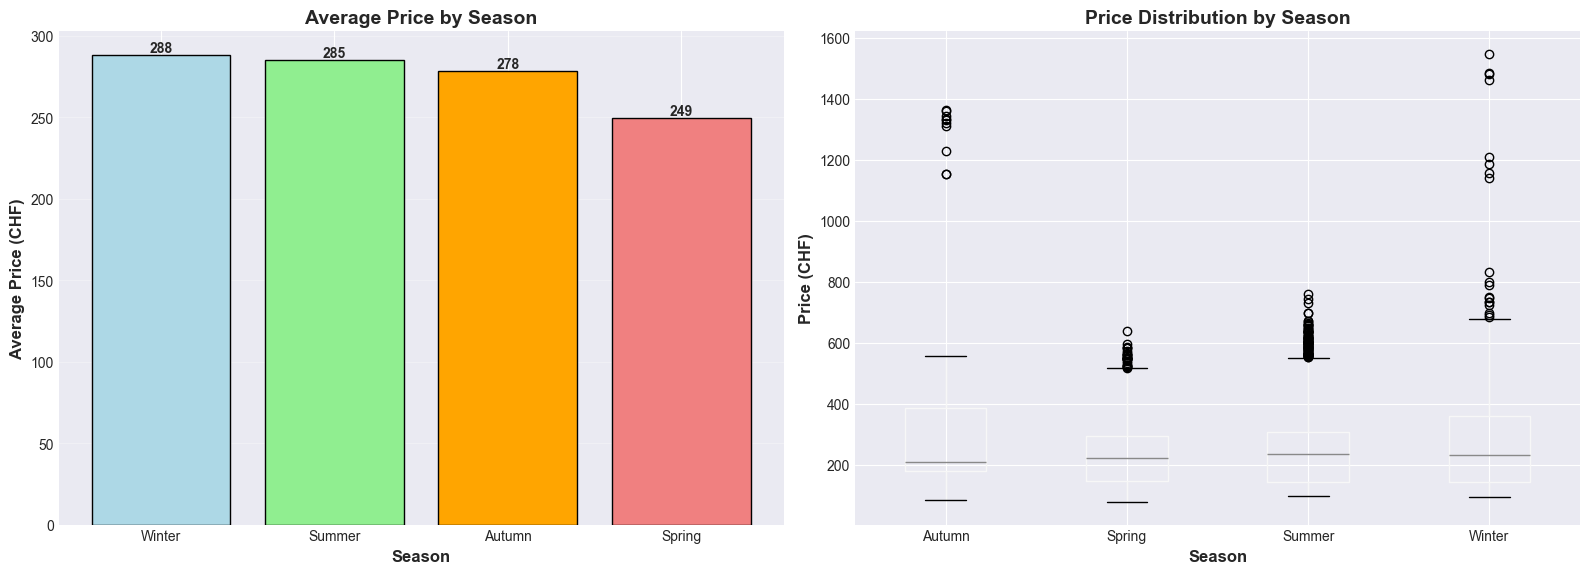


Seasonal Statistics:
          mean  median  count
season                       
Winter  288.16  232.44    363
Summer  284.88  235.59    589
Autumn  278.28  210.04    420
Spring  249.48  223.50    551


In [30]:
season_avg = df.groupby('season')['price'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].bar(season_avg.index, season_avg.values, 
                  color=['lightblue', 'lightgreen', 'orange', 'lightcoral'], edgecolor='black')
axes[0].set_xlabel('Season', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Price (CHF)', fontsize=12, fontweight='bold')
axes[0].set_title('Average Price by Season', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}', ha='center', va='bottom', fontweight='bold')

df.boxplot(column='price', by='season', ax=axes[1])
axes[1].set_xlabel('Season', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price (CHF)', fontsize=12, fontweight='bold')
axes[1].set_title('Price Distribution by Season', fontsize=14, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

season_stats = df.groupby('season')['price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False).round(2)
print("\nSeasonal Statistics:")
print(season_stats.to_string())

## 9. Ski Season Impact on Pricing

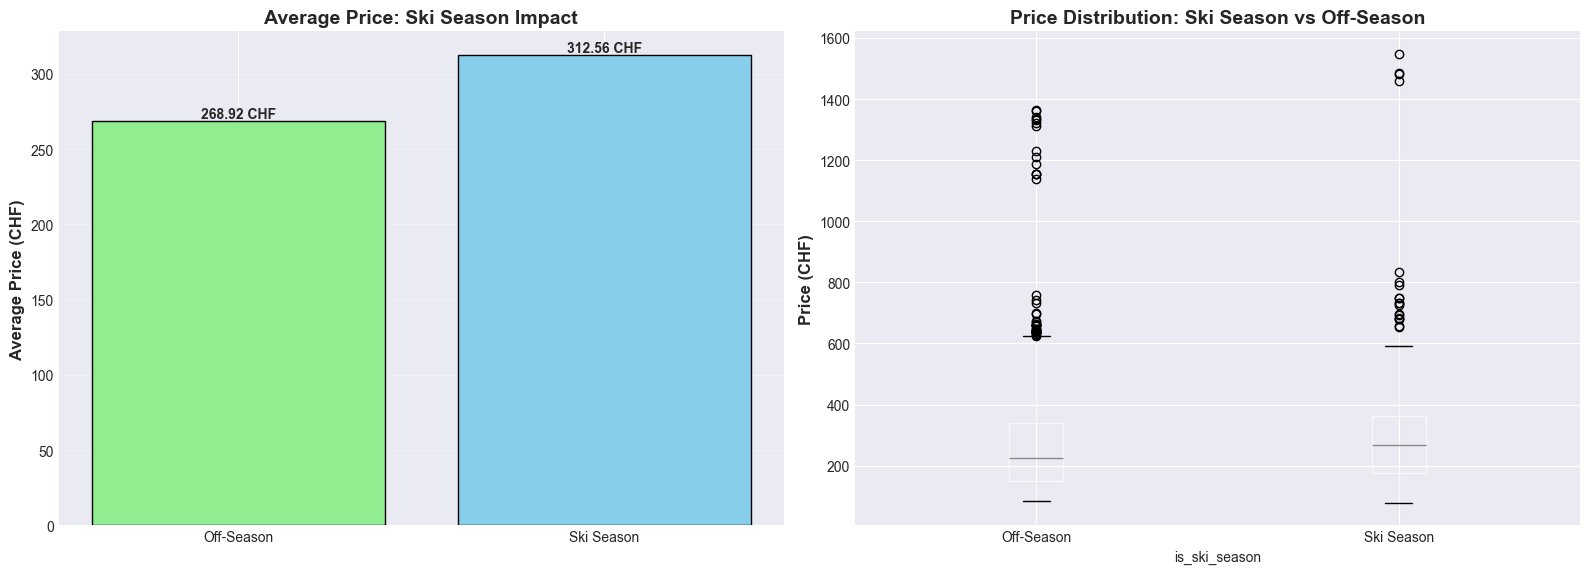


Ski Season Analysis:
              mean  median     std  count
Off-Season  268.92  223.66  171.27   1703
Ski Season  312.56  266.02  227.56    220


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ski_comparison = df.groupby('is_ski_season')['price'].mean()
axes[0].bar(['Off-Season', 'Ski Season'], ski_comparison.values, 
           color=['lightgreen', 'skyblue'], edgecolor='black')
axes[0].set_ylabel('Average Price (CHF)', fontsize=12, fontweight='bold')
axes[0].set_title('Average Price: Ski Season Impact', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(ski_comparison.values):
    axes[0].text(i, v, f'{v:.2f} CHF', ha='center', va='bottom', fontweight='bold')

df.boxplot(column='price', by='is_ski_season', ax=axes[1])
axes[1].set_xticklabels(['Off-Season', 'Ski Season'])
axes[1].set_ylabel('Price (CHF)', fontsize=12, fontweight='bold')
axes[1].set_title('Price Distribution: Ski Season vs Off-Season', fontsize=14, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nSki Season Analysis:")
ski_stats = df.groupby('is_ski_season')['price'].agg(['mean', 'median', 'std', 'count']).round(2)
ski_stats.index = ['Off-Season', 'Ski Season']
print(ski_stats.to_string())

## 10. Price vs Altitude (for Mountain Locations)

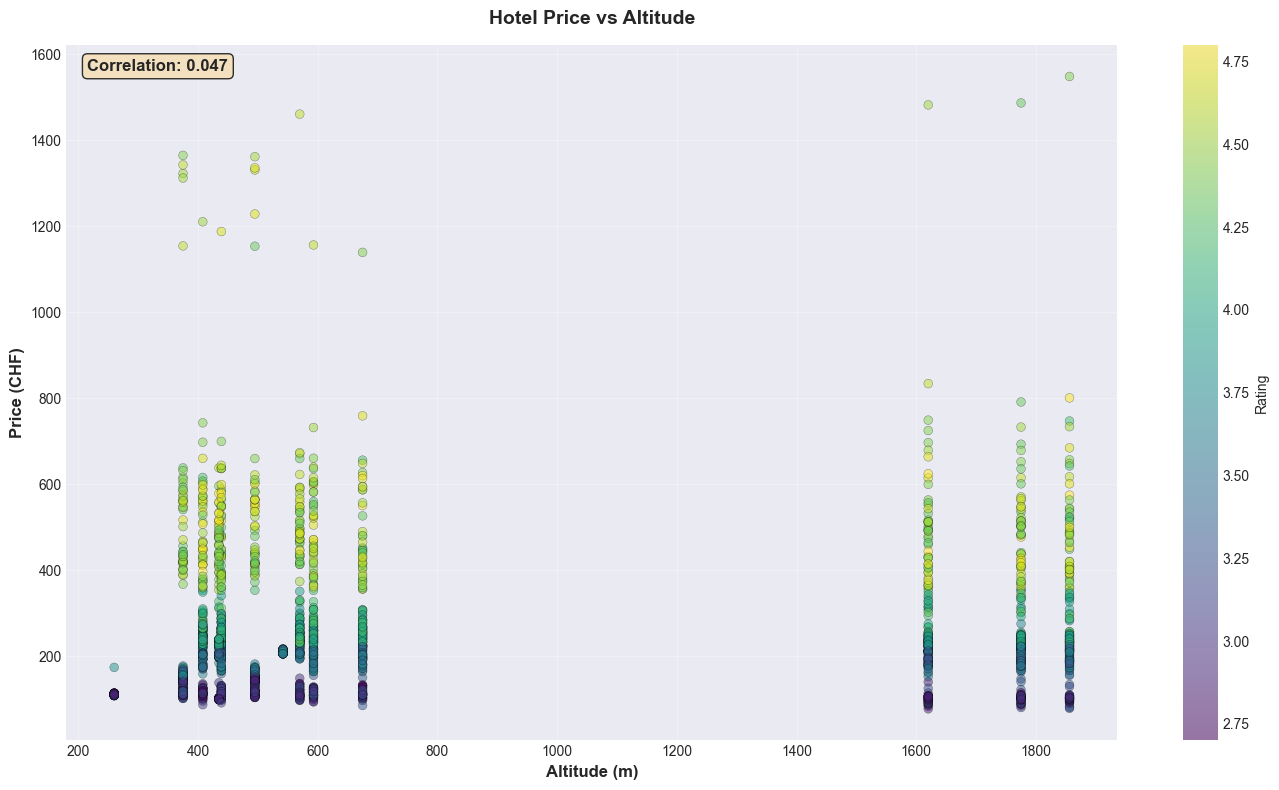


Price-Altitude Correlation: 0.0466


In [32]:
plt.figure(figsize=(14, 8))
plt.scatter(df['altitude'], df['price'], alpha=0.5, s=40, c=df['rating'], cmap='viridis', edgecolors='black', linewidth=0.3)
plt.xlabel('Altitude (m)', fontsize=12, fontweight='bold')
plt.ylabel('Price (CHF)', fontsize=12, fontweight='bold')
plt.title('Hotel Price vs Altitude', fontsize=14, fontweight='bold', pad=15)
plt.colorbar(label='Rating')
plt.grid(True, alpha=0.3)

altitude_corr = df['price'].corr(df['altitude'])
plt.text(0.02, 0.98, f'Correlation: {altitude_corr:.3f}', 
        transform=plt.gca().transAxes, fontsize=12, fontweight='bold',
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\nPrice-Altitude Correlation: {altitude_corr:.4f}")

## 11. Temperature Impact on Pricing

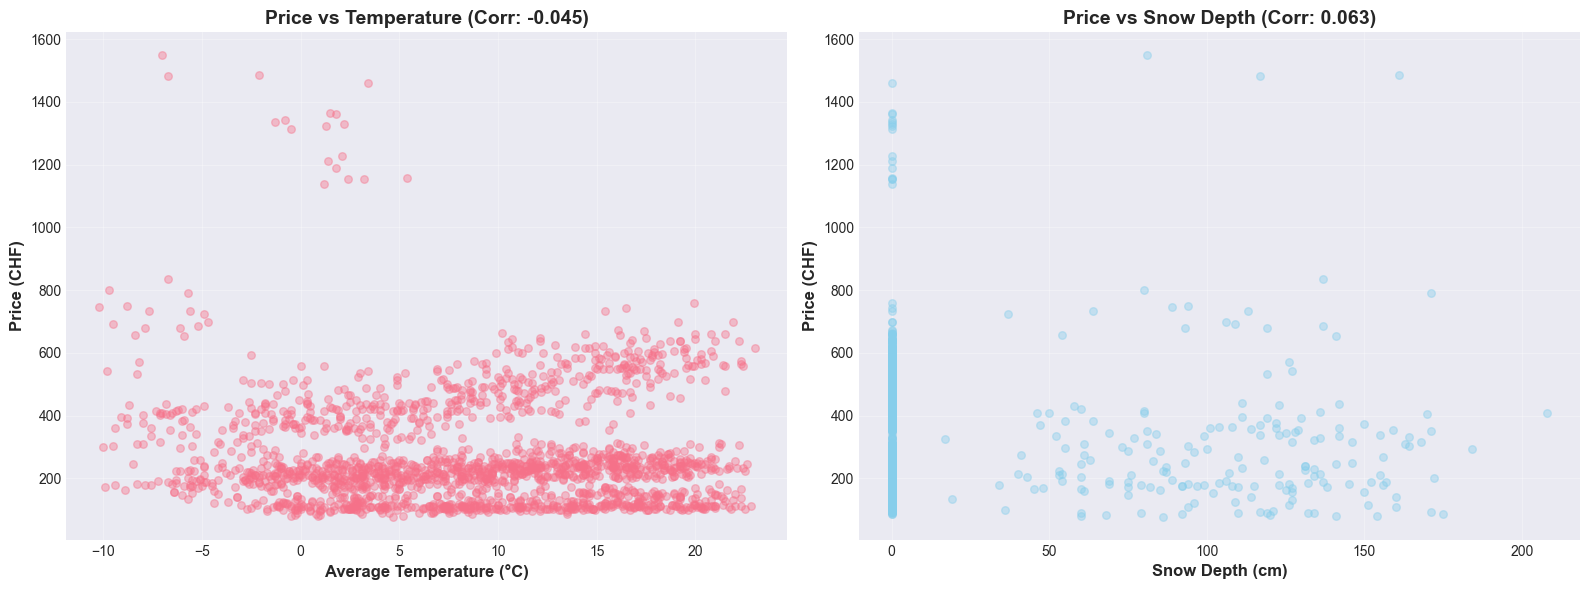


Temperature-Price Correlation: -0.0448
Snow Depth-Price Correlation: 0.0628


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['temp_avg'], df['price'], alpha=0.4, s=30)
temp_corr = df['price'].corr(df['temp_avg'])
axes[0].set_xlabel('Average Temperature (°C)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (CHF)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Price vs Temperature (Corr: {temp_corr:.3f})', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df['snow_depth_cm'], df['price'], alpha=0.4, s=30, color='skyblue')
snow_corr = df['price'].corr(df['snow_depth_cm'])
axes[1].set_xlabel('Snow Depth (cm)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price (CHF)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Price vs Snow Depth (Corr: {snow_corr:.3f})', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTemperature-Price Correlation: {temp_corr:.4f}")
print(f"Snow Depth-Price Correlation: {snow_corr:.4f}")

## 12. Correlation Heatmap of Key Numeric Variables

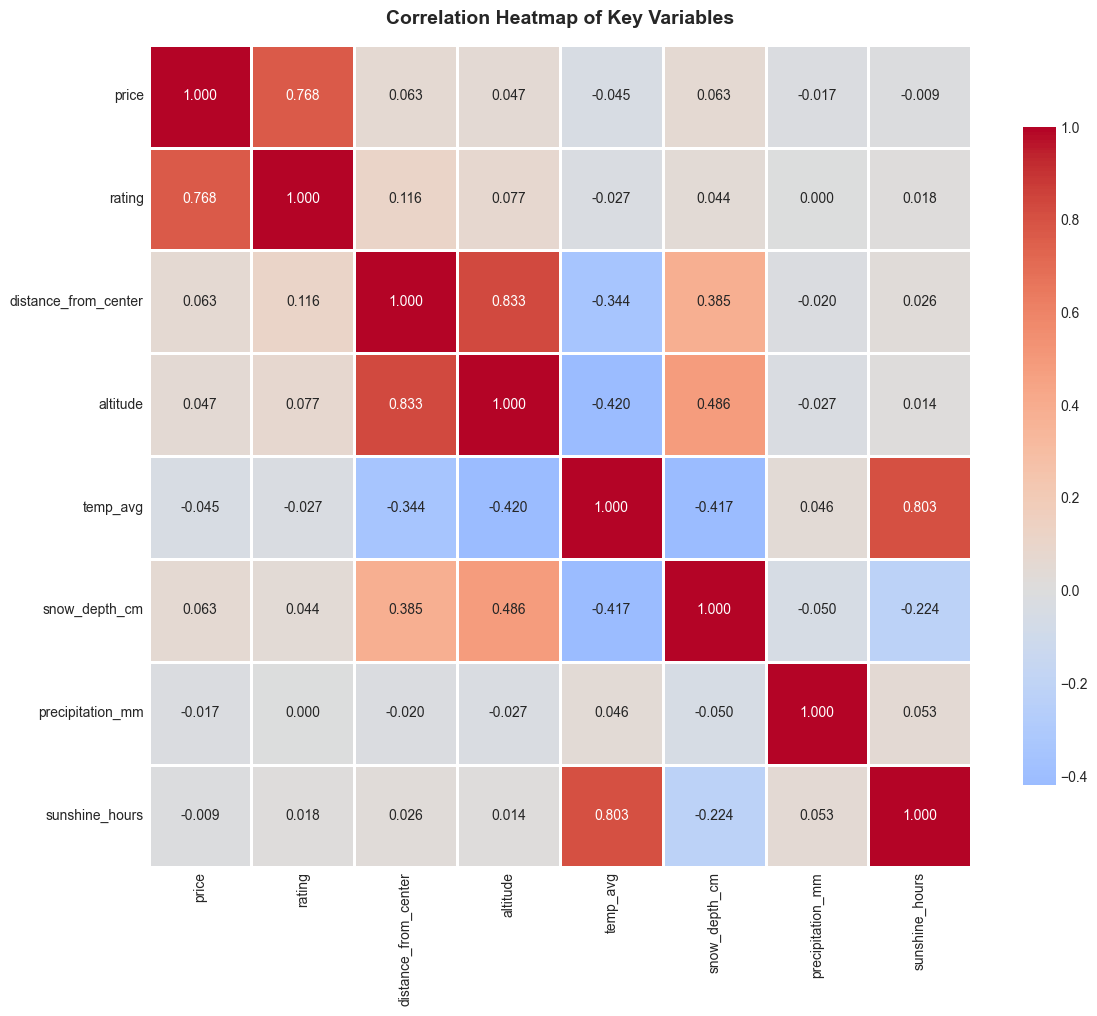


Top Correlations with Price:
price                   1.000000
rating                  0.768172
snow_depth_cm           0.062762
distance_from_center    0.062531
altitude                0.046570
sunshine_hours         -0.009295
precipitation_mm       -0.016975
temp_avg               -0.044757


In [34]:
numeric_cols = ['price', 'rating', 'distance_from_center', 'altitude', 'temp_avg', 
               'snow_depth_cm', 'precipitation_mm', 'sunshine_hours']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
           center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Key Variables', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nTop Correlations with Price:")
price_corr = correlation_matrix['price'].sort_values(ascending=False)
print(price_corr.to_string())

## 13. Destination Type Analysis

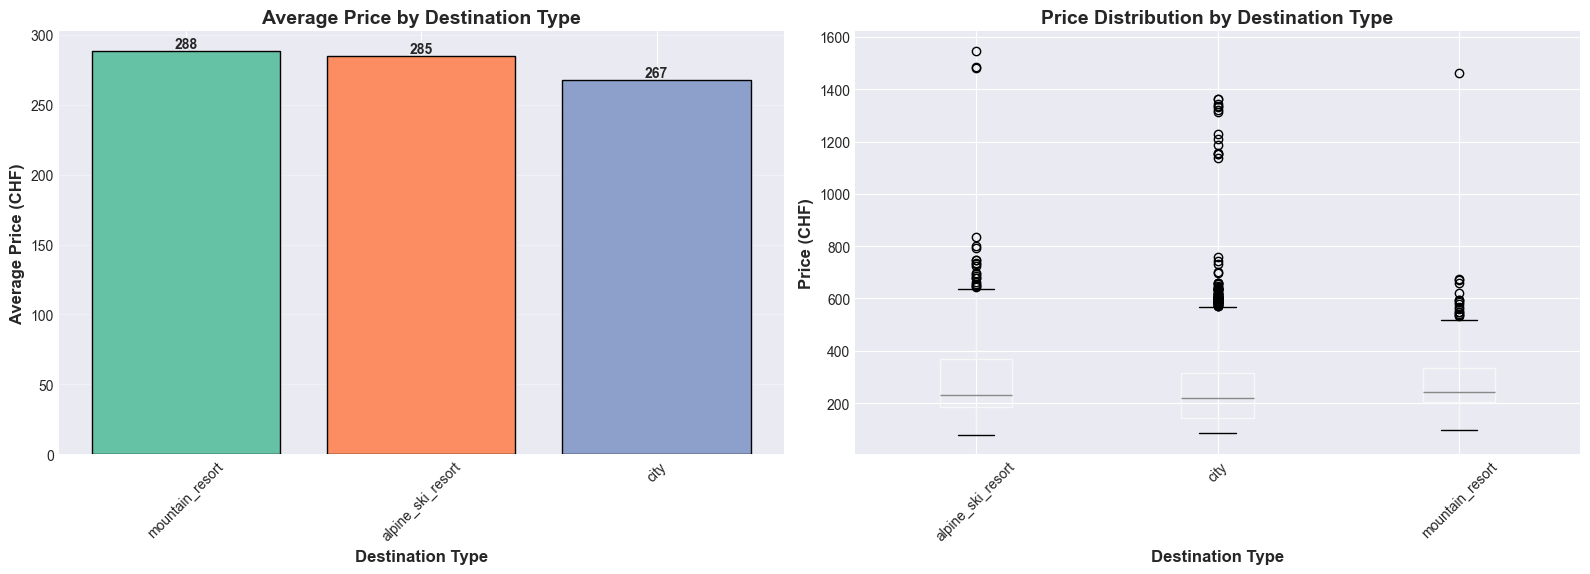


Destination Type Statistics:
                     mean  median  count
destination_type                        
mountain_resort    288.06  241.76    172
alpine_ski_resort  284.67  229.40    522
city               267.37  217.48   1229


In [35]:
dest_avg = df.groupby('destination_type')['price'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].bar(dest_avg.index, dest_avg.values, 
                  color=sns.color_palette("Set2", len(dest_avg)), edgecolor='black')
axes[0].set_xlabel('Destination Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Price (CHF)', fontsize=12, fontweight='bold')
axes[0].set_title('Average Price by Destination Type', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}', ha='center', va='bottom', fontweight='bold')

df.boxplot(column='price', by='destination_type', ax=axes[1])
axes[1].set_xlabel('Destination Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price (CHF)', fontsize=12, fontweight='bold')
axes[1].set_title('Price Distribution by Destination Type', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle('')

plt.tight_layout()
plt.show()

dest_stats = df.groupby('destination_type')['price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False).round(2)
print("\nDestination Type Statistics:")
print(dest_stats.to_string())

## Summary Statistics Table

In [36]:
print("\n" + "="*80)
print("COMPREHENSIVE DATA SUMMARY")
print("="*80)

print("\nDataset Overview:")
print(f"  Total Records: {len(df):,}")
print(f"  Unique Hotels: {df['hotel_id'].nunique():,}")
print(f"  Locations: {df['location'].nunique()}")
print(f"  Date Range: {df['search_date'].min().strftime('%Y-%m-%d')} to {df['search_date'].max().strftime('%Y-%m-%d')}")

print("\nPrice Statistics:")
print(f"  Mean: {df['price'].mean():.2f} CHF")
print(f"  Median: {df['price'].median():.2f} CHF")
print(f"  Std Dev: {df['price'].std():.2f} CHF")
print(f"  Min: {df['price'].min():.2f} CHF")
print(f"  Max: {df['price'].max():.2f} CHF")

print("\nKey Correlations with Price:")
print(f"  Rating: {df['price'].corr(df['rating']):.4f}")
print(f"  Distance from Center: {df['price'].corr(df['distance_from_center']):.4f}")
print(f"  Altitude: {df['price'].corr(df['altitude']):.4f}")
print(f"  Temperature: {df['price'].corr(df['temp_avg']):.4f}")
print(f"  Snow Depth: {df['price'].corr(df['snow_depth_cm']):.4f}")

print("\n" + "="*80)


COMPREHENSIVE DATA SUMMARY

Dataset Overview:
  Total Records: 1,923
  Unique Hotels: 12
  Locations: 13
  Date Range: 2026-01-05 to 2026-12-07

Price Statistics:
  Mean: 273.92 CHF
  Median: 226.83 CHF
  Std Dev: 179.08 CHF
  Min: 77.87 CHF
  Max: 1548.06 CHF

Key Correlations with Price:
  Rating: 0.7682
  Distance from Center: 0.0625
  Altitude: 0.0466
  Temperature: -0.0448
  Snow Depth: 0.0628

